#**BÁO CÁO EDA HỆ THỐNG PHÂN TÍCH VÀ DỰ BÁO TIÊU THỤ ĐIỆN NĂNG BẰNG TRÍ TUỆ NHÂN TẠO (AI)**


##1. **Giới thiệu dự án (Introduction)**
Trong bối cảnh hiện đại, việc quản lý năng lượng hiệu quả là bài toán then chốt để đảm bảo an ninh năng lượng và tối ưu hóa chi phí vận hành. Dự án này tập trung vào việc khai thác bộ dữ liệu tiêu thụ điện năng theo giờ của khu vực PJME (PJM Interconnection LLC).

Mục tiêu cốt lõi là:
- Phân tích (EDA): Tìm ra các quy luật tiềm ẩn, tính mùa vụ và xu hướng tiêu thụ điện.
- Tiền xử lý: Làm sạch và tạo ra các đặc trưng (features) quan trọng từ chuỗi thời gian.
- Dự báo (Forecasting): Xây dựng nền tảng dữ liệu tin cậy để huấn luyện các mô hình AI (như Prophet, LSTM, XGBoost) nhằm dự báo nhu cầu trong tương lai.

##**2. Tổng quan về tập dữ liệu (Dataset Overview)**
Tập dữ liệu được sử dụng trong dự án này ghi lại mức tiêu thụ điện năng theo giờ của khu vực PJM East (PJME), một phần của lưới điện PJM Interconnection phục vụ khu vực miền Đông Hoa Kỳ.

2.1. Cấu trúc và Quy mô

- Tổng số bản ghi: $145,366$ dòng dữ liệu.
- Số lượng cột: $02$ cột chính:
    - Datetime: Thời gian ghi nhận dữ liệu (định dạng YYYY-MM-DD HH:MM:SS).
    - PJME_MW: Mức tiêu thụ điện năng tại thời điểm tương ứng, đơn vị tính là Megawatt (MW).
- Phạm vi thời gian: Dữ liệu kéo dài hơn 16 năm, từ ngày $01/01/2002$ đến ngày $03/08/2018$.

3.2. Đặc điểm thống kê sơ bộ
Dựa trên các chỉ số thống kê mô tả, mức tiêu thụ điện năng trong khu vực có những đặc điểm sau:
- Mức tiêu thụ trung bình: $\approx 32,080$ MW.
- Giá trị thấp nhất (Min): $14,544$ MW (Thường rơi vào các khung giờ thấp điểm hoặc điều kiện thời tiết lý tưởng).
- Giá trị cao nhất (Max): $62,009$ MW (Phản ánh các thời điểm nhu cầu cực đỉnh trong các đợt nóng hoặc lạnh kỷ lục).
- Độ lệch chuẩn: $\approx 6,464$ MW, cho thấy sự biến động đáng kể về nhu cầu điện năng giữa các khung giờ và mùa trong năm.

3.3. Tình trạng dữ liệu
- Giá trị thiếu (Missing Values): Tập dữ liệu hoàn chỉnh, không có giá trị trống (null) trong cả hai cột.
- Dữ liệu trùng lặp (Duplicates): Không có dòng dữ liệu nào bị trùng lặp hoàn toàn.
- Tính liên tục: Mặc dù không có giá trị trống về mặt bản ghi, chuỗi thời gian cần được kiểm tra các mốc giờ bị khuyết do các yếu tố kỹ thuật hoặc thay đổi giờ mùa hè (DST) trước khi thực hiện dự báo.

##3. Phân tích dữ liệu

###1. Import thư viện & Đọc dữ liệu



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use("default")
sns.set_theme(style="whitegrid")

In [4]:
DATA_PATH = '../data/sample/PJME_hourly.csv'
df = pd.read_csv(DATA_PATH)
df.head()

,Datetime,PJME_MW
0,12/31/2002 1:00,26498
1,12/31/2002 2:00,25147
2,12/31/2002 3:00,24574
3,12/31/2002 4:00,24393
4,12/31/2002 5:00,24860


###2. Kiểm tra cấu trúc dữ liệu

In [5]:
print("Kích thước dữ liệu:", df.shape)
print("\nTên cột:", df.columns.tolist())
print("\nThông tin dữ liệu:")
print(df.info())


Kích thước dữ liệu: (145366, 2)

Tên cột: ['Datetime', 'PJME_MW']

Thông tin dữ liệu:
<class 'pandas.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   Datetime  145366 non-null  str  
 1   PJME_MW   145366 non-null  int64
dtypes: int64(1), str(1)
memory usage: 2.2 MB
None


Nhận xét: Bộ dữ liệu gồm 145,366 dòng và 2 cột, trong đó cột Datetime là thời gian và PJME_MW là mức tiêu thụ điện năng. Dữ liệu có kích thước đủ lớn để phân tích chuỗi thời gian và huấn luyện các mô hình dự báo.

###3. Chuyển kiểu dữ liệu và sắp xếp thời gian

In [6]:
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.sort_values("Datetime").reset_index(drop=True)

df.head()

,Datetime,PJME_MW
0,2002-01-01 01:00:00,30393
1,2002-01-01 02:00:00,29265
2,2002-01-01 03:00:00,28357
3,2002-01-01 04:00:00,27899
4,2002-01-01 05:00:00,28057


###4. Kiểm tra giá trị thiếu, trùng lặp, thống kê mô tả


In [7]:
print("Giá trị thiếu:")
print(df.isnull().sum())

print("\nSố dòng trùng hoàn toàn:", df.duplicated().sum())

print("\nThống kê mô tả biến PJME_MW:")
print(df["PJME_MW"].describe())

Giá trị thiếu:
Datetime    0
PJME_MW     0
dtype: int64

Số dòng trùng hoàn toàn: 0

Thống kê mô tả biến PJME_MW:
count    145366.000000
mean      32080.222831
std        6464.012166
min       14544.000000
25%       27573.000000
50%       31421.000000
75%       35650.000000
max       62009.000000
Name: PJME_MW, dtype: float64


Nhận xét :

Kết quả cho thấy dữ liệu không có giá trị thiếu và không có dòng trùng hoàn toàn. Biến PJME_MW có giá trị trung bình khoảng 32,080 MW, dao động từ 14,544 MW đến 62,009 MW, cho thấy mức tiêu thụ điện biến thiên khá lớn theo thời gian.

###5. Kiểm tra tính liên tục theo giờ


In [8]:
full_range = pd.date_range(start=df["Datetime"].min(), end=df["Datetime"].max(), freq="h")
missing_timestamps = full_range.difference(df["Datetime"])

print("Tổng số mốc giờ kỳ vọng:", len(full_range))
print("Số mốc giờ bị thiếu:", len(missing_timestamps))
print("\n10 mốc giờ thiếu đầu tiên:")
print(missing_timestamps[:10])

duplicate_timestamps = df[df["Datetime"].duplicated(keep=False)].sort_values("Datetime")
print("\nSố timestamp bị lặp:", duplicate_timestamps.shape[0])
duplicate_timestamps.head(10)

Tổng số mốc giờ kỳ vọng: 145392
Số mốc giờ bị thiếu: 30

10 mốc giờ thiếu đầu tiên:
DatetimeIndex(['2002-04-07 03:00:00', '2002-10-27 02:00:00',
               '2003-04-06 03:00:00', '2003-10-26 02:00:00',
               '2004-04-04 03:00:00', '2004-10-31 02:00:00',
               '2005-04-03 03:00:00', '2005-10-30 02:00:00',
               '2006-04-02 03:00:00', '2006-10-29 02:00:00'],
              dtype='datetime64[us]', freq=None)

Số timestamp bị lặp: 8


,Datetime,PJME_MW
112487,2014-11-02 02:00:00,23755
112488,2014-11-02 02:00:00,22935
121223,2015-11-01 02:00:00,21567
121224,2015-11-01 02:00:00,21171
130127,2016-11-06 02:00:00,20795
130128,2016-11-06 02:00:00,21692
138863,2017-11-05 02:00:00,21236
138864,2017-11-05 02:00:00,20666


Nhận xét:

Mặc dù dữ liệu không thiếu giá trị ở mức bản ghi, nhưng khi xét theo chuỗi thời gian liên tục theo giờ thì vẫn có một số mốc giờ bị thiếu hoặc lặp. Đây là hiện tượng thường gặp trong dữ liệu điện năng theo giờ và cần được lưu ý trước khi thực hiện các kỹ thuật như decomposition hoặc resampling.

###6. Vẽ biểu đồ chuỗi thời gian tổng thể

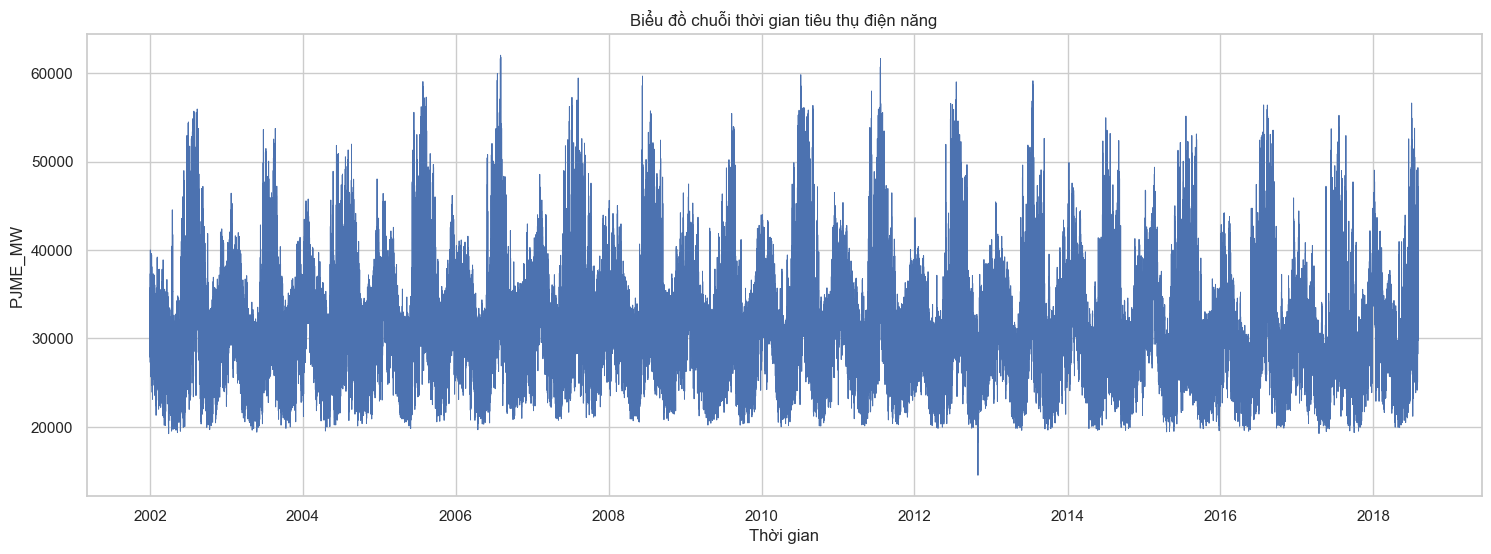

In [9]:
plt.figure(figsize=(18,6))
plt.plot(df["Datetime"], df["PJME_MW"], linewidth=0.7)
plt.title("Biểu đồ chuỗi thời gian tiêu thụ điện năng")
plt.xlabel("Thời gian")
plt.ylabel("PJME_MW")
plt.show()

Nhận xét :

Biểu đồ chuỗi thời gian cho thấy mức tiêu thụ điện biến động liên tục và có quy luật theo thời gian. Dữ liệu xuất hiện nhiều chu kỳ lặp lại, thể hiện rõ tính mùa vụ và đặc trưng điển hình của chuỗi thời gian tiêu thụ điện năng.

###7. Phân phối dữ liệu và boxplot


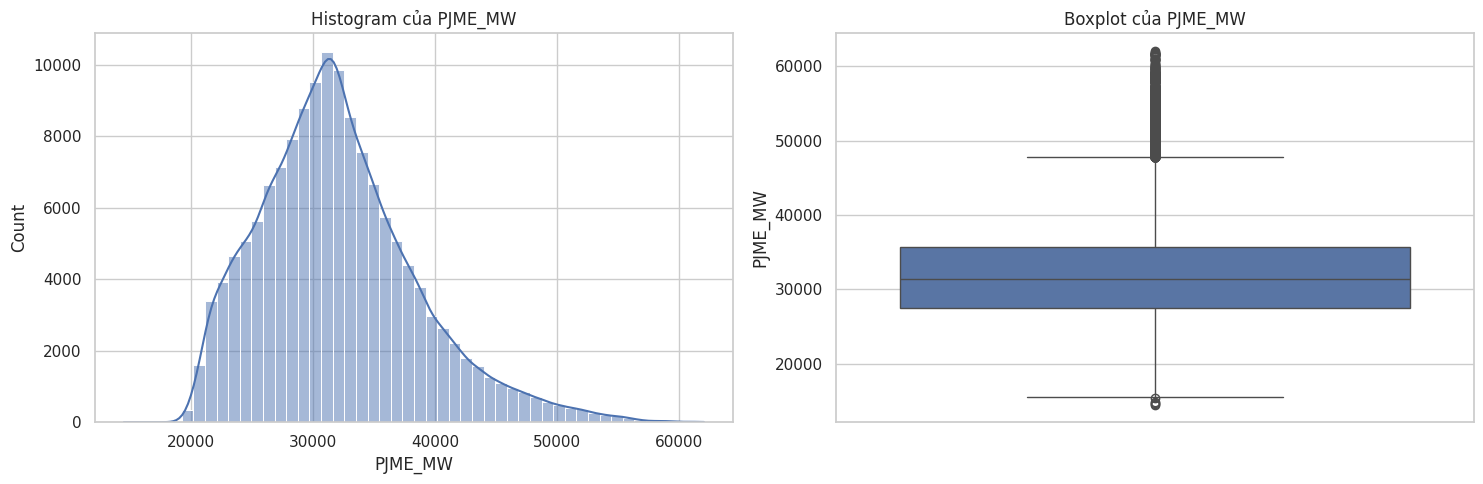

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))

sns.histplot(df["PJME_MW"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Histogram của PJME_MW")

sns.boxplot(y=df["PJME_MW"], ax=axes[1])
axes[1].set_title("Boxplot của PJME_MW")

plt.tight_layout()
plt.show()

Nhận xét :

- Biểu đồ histogram cho thấy dữ liệu PJME_MW tập trung chủ yếu quanh khoảng 27.000 đến 35.000 MW, với đỉnh phân bố gần 30.000 MW. Phân phối có xu hướng lệch phải, cho thấy phần lớn thời điểm mức tiêu thụ điện ở mức trung bình nhưng vẫn có một số giai đoạn tăng rất cao.
- Boxplot cho thấy trung vị nằm khoảng 31.000 MW và xuất hiện khá nhiều giá trị ngoại lệ, đặc biệt ở phía trên. Điều này phản ánh dữ liệu tiêu thụ điện có biến động mạnh ở một số thời điểm cao điểm và cần được lưu ý trong quá trình xây dựng mô hình dự báo.

###8. Tạo các đặc trưng thời gian

In [10]:
eda_df = df.copy()

eda_df["hour"] = eda_df["Datetime"].dt.hour
eda_df["dayofweek"] = eda_df["Datetime"].dt.dayofweek
eda_df["day_name"] = eda_df["Datetime"].dt.day_name()
eda_df["month"] = eda_df["Datetime"].dt.month
eda_df["year"] = eda_df["Datetime"].dt.year
eda_df["date"] = eda_df["Datetime"].dt.date

eda_df.head()

,Datetime,PJME_MW,hour,dayofweek,day_name,month,year,date
0,2002-01-01 01:00:00,30393,1,1,Tuesday,1,2002,2002-01-01
1,2002-01-01 02:00:00,29265,2,1,Tuesday,1,2002,2002-01-01
2,2002-01-01 03:00:00,28357,3,1,Tuesday,1,2002,2002-01-01
3,2002-01-01 04:00:00,27899,4,1,Tuesday,1,2002,2002-01-01
4,2002-01-01 05:00:00,28057,5,1,Tuesday,1,2002,2002-01-01


Nhận xét :

Các đặc trưng thời gian được tạo ra từ cột Datetime gồm hour, dayofweek, day_name, month, year và date, giúp chuyển dữ liệu thời gian thành các biến dễ phân tích hơn. Những đặc trưng này rất quan trọng vì mức tiêu thụ điện thường biến động theo giờ trong ngày, khác nhau giữa ngày trong tuần, giữa các tháng và giữa các năm. Nhờ đó, ta có thể phân tích rõ xu hướng, tính mùa vụ và các chu kỳ lặp lại của dữ liệu điện năng. Đây cũng là cơ sở quan trọng để trực quan hóa dữ liệu và xây dựng mô hình dự báo chính xác hơn.

###9. Phân tích theo giờ trong ngày

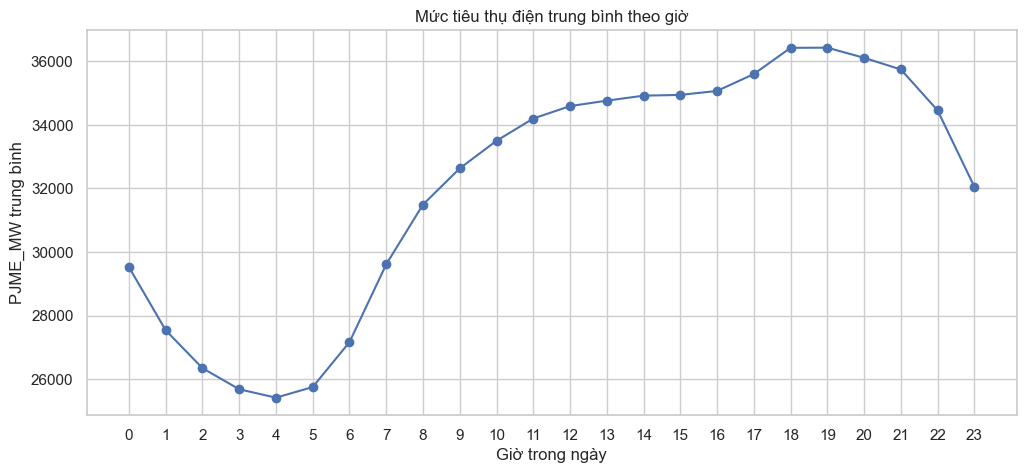

Giờ có mức tiêu thụ trung bình cao nhất: 19
Giờ có mức tiêu thụ trung bình thấp nhất: 4


In [11]:
hourly_mean = eda_df.groupby("hour")["PJME_MW"].mean()

plt.figure(figsize=(12,5))
plt.plot(hourly_mean.index, hourly_mean.values, marker="o")
plt.title("Mức tiêu thụ điện trung bình theo giờ")
plt.xlabel("Giờ trong ngày")
plt.ylabel("PJME_MW trung bình")
plt.xticks(range(24))
plt.show()

print("Giờ có mức tiêu thụ trung bình cao nhất:", hourly_mean.idxmax())
print("Giờ có mức tiêu thụ trung bình thấp nhất:", hourly_mean.idxmin())

Nhận xét :

Biểu đồ cho thấy mức tiêu thụ điện thay đổi rất rõ theo từng giờ trong ngày. Nhu cầu điện giảm dần từ đêm khuya đến rạng sáng và đạt mức thấp nhất vào khoảng 4 giờ sáng, sau đó tăng mạnh từ buổi sáng và duy trì ở mức cao trong buổi chiều đến tối. Mức tiêu thụ điện trung bình cao nhất rơi vào khoảng 19 giờ, phản ánh đây là khung giờ cao điểm sử dụng điện. Điều này cho thấy dữ liệu có tính chu kỳ theo ngày rất rõ và đặc trưng giờ là một biến quan trọng trong mô hình dự báo.

###10. Phân tích theo ngày trong tuần

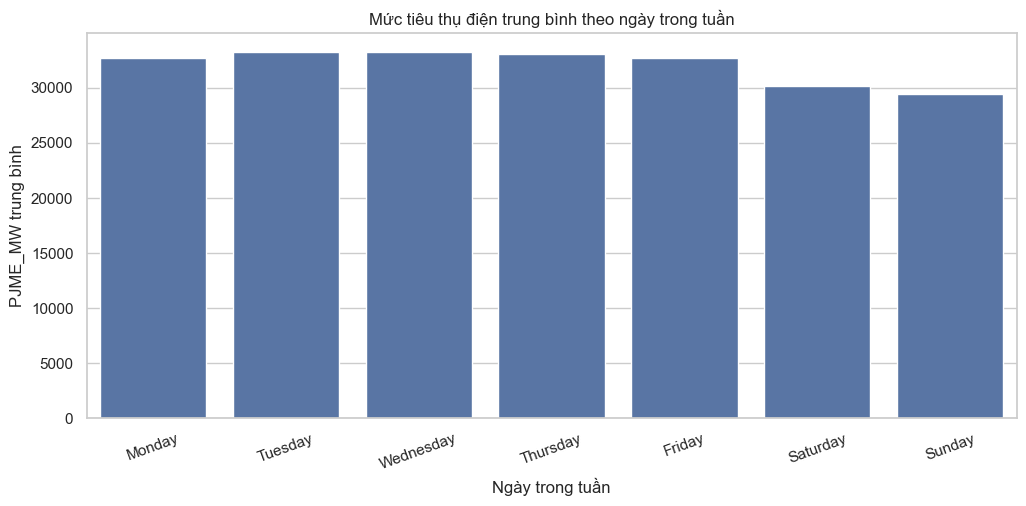

day_name
Monday       32672.028420
Tuesday      33272.265746
Wednesday    33261.497498
Thursday     33085.857727
Friday       32688.097688
Saturday     30162.880588
Sunday       29411.869930
Name: PJME_MW, dtype: float64


In [12]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_mean = eda_df.groupby("day_name")["PJME_MW"].mean().reindex(weekday_order)

plt.figure(figsize=(12,5))
sns.barplot(x=weekday_mean.index, y=weekday_mean.values)
plt.title("Mức tiêu thụ điện trung bình theo ngày trong tuần")
plt.xlabel("Ngày trong tuần")
plt.ylabel("PJME_MW trung bình")
plt.xticks(rotation=20)
plt.show()

print(weekday_mean)

Nhận xét :

Biểu đồ cho thấy mức tiêu thụ điện trung bình có sự khác biệt giữa các ngày trong tuần nhưng không chênh lệch quá lớn. Các ngày từ **thứ Hai đến thứ Sáu** nhìn chung có mức tiêu thụ cao hơn, trong đó **thứ Ba và thứ Tư** là những ngày cao nhất. Ngược lại, mức tiêu thụ điện** giảm rõ vào cuối tuần**, đặc biệt **Chủ nhật là ngày thấp nhất**. Điều này phản ánh nhu cầu sử dụng điện thường cao hơn trong các ngày làm việc và giảm vào những ngày nghỉ.

###11. Phân tích theo tháng

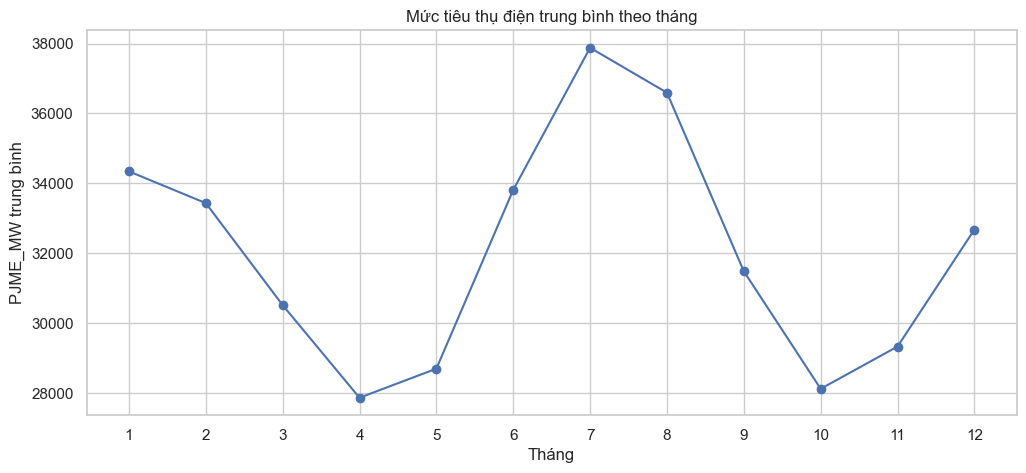

Tháng cao nhất: 7
Tháng thấp nhất: 4
month
1     34343.246462
2     33434.972049
3     30514.903609
4     27863.339354
5     28695.362113
6     33811.799183
7     37881.972881
8     36595.959675
9     31484.054688
10    28119.228675
11    29328.733872
12    32676.247669
Name: PJME_MW, dtype: float64


In [13]:
monthly_mean = eda_df.groupby("month")["PJME_MW"].mean()

plt.figure(figsize=(12,5))
plt.plot(monthly_mean.index, monthly_mean.values, marker="o")
plt.title("Mức tiêu thụ điện trung bình theo tháng")
plt.xlabel("Tháng")
plt.ylabel("PJME_MW trung bình")
plt.xticks(range(1,13))
plt.show()

print("Tháng cao nhất:", monthly_mean.idxmax())
print("Tháng thấp nhất:", monthly_mean.idxmin())
print(monthly_mean)

Nhận xét :

Biểu đồ cho thấy mức tiêu thụ điện trung bình thay đổi khá rõ theo từng tháng, thể hiện tính mùa vụ theo năm. Nhu cầu điện tăng mạnh từ tháng 6 và **đạt đỉnh vào tháng 7**, sau đó giảm dần ở các tháng tiếp theo. Trong khi đó, **tháng 4 là tháng có mức tiêu thụ điện trung bình thấp nhất**. Điều này cho thấy yếu tố thời tiết và nhu cầu sử dụng điện theo mùa có ảnh hưởng lớn đến dữ liệu, rất quan trọng trong bài toán dự báo điện năng.

###12. Phân tích theo năm

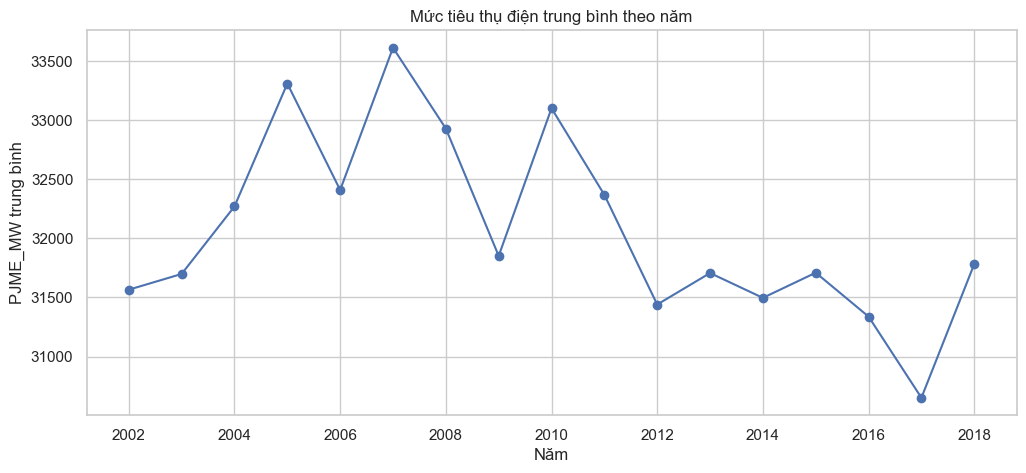

year
2002    31565.617106
2003    31698.758621
2004    32270.434867
2005    33310.478648
2006    32409.269696
2007    33613.468600
2008    32929.593373
2009    31851.533683
2010    33101.172662
2011    32368.308518
2012    31440.107265
2013    31706.525120
2014    31496.406963
2015    31709.394178
2016    31337.833106
2017    30650.911644
2018    31782.598715
Name: PJME_MW, dtype: float64


In [14]:
yearly_mean = eda_df.groupby("year")["PJME_MW"].mean()

plt.figure(figsize=(12,5))
plt.plot(yearly_mean.index, yearly_mean.values, marker="o")
plt.title("Mức tiêu thụ điện trung bình theo năm")
plt.xlabel("Năm")
plt.ylabel("PJME_MW trung bình")
plt.show()

print(yearly_mean)

Nhận xét :

Biểu đồ cho thấy mức tiêu thụ điện trung bình theo năm có biến động nhưng không tăng hoặc giảm theo một xu hướng hoàn toàn ổn định. Giai đoạn từ **2002 đến 2007** nhìn chung có xu hướng tăng, trong đó **năm 2007 đạt mức cao nhất**. Sau đó, mức tiêu thụ điện dao động lên xuống qua các năm và giảm khá rõ ở một số giai đoạn như 2009, 2012 và 2017. Điều này cho thấy nhu cầu điện ngoài yếu tố thời gian còn chịu ảnh hưởng của nhiều yếu tố khác như thời tiết, kinh tế và nhu cầu sử dụng điện thực tế trong từng năm.

###13. Rolling mean để nhìn xu hướng

*Trung bình trượt là một kỹ thuật cực kỳ quan trọng để làm mượt dữ liệu và làm lộ ra các xu hướng ẩn bên dưới các biến động nhiễu.*

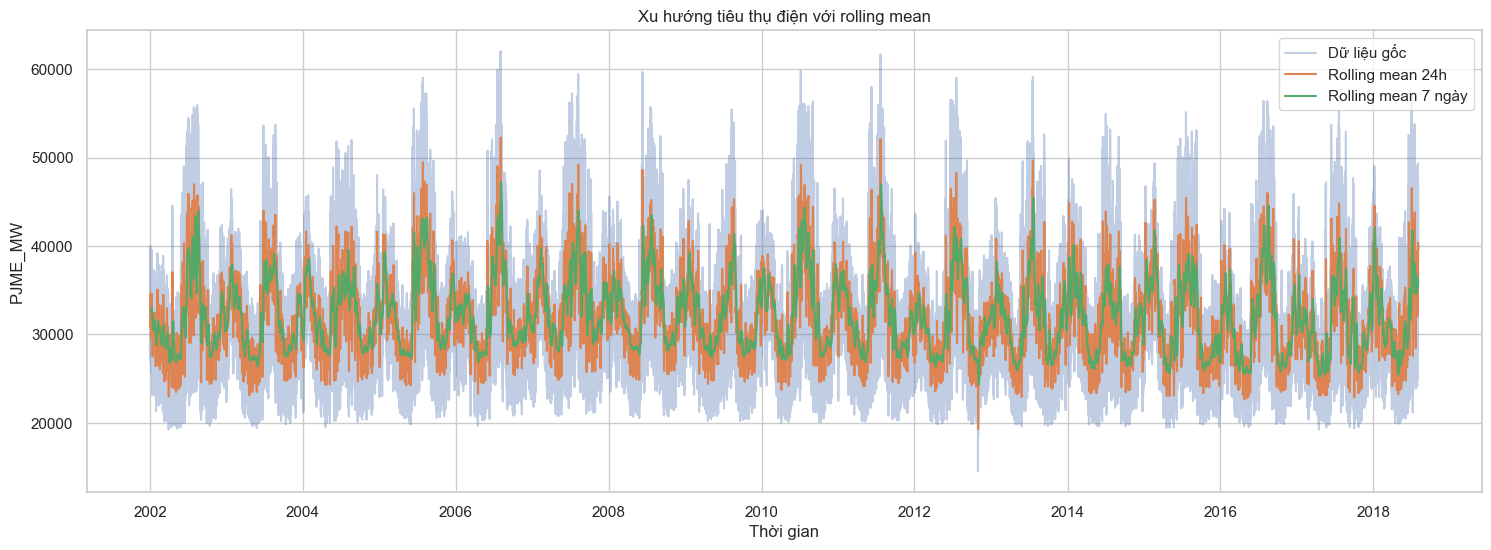

In [15]:
ts_df = df.copy().set_index("Datetime")

ts_df["rolling_24h"] = ts_df["PJME_MW"].rolling(window=24).mean()
ts_df["rolling_7d"] = ts_df["PJME_MW"].rolling(window=24*7).mean()

plt.figure(figsize=(18,6))
plt.plot(ts_df.index, ts_df["PJME_MW"], alpha=0.35, label="Dữ liệu gốc")
plt.plot(ts_df.index, ts_df["rolling_24h"], label="Rolling mean 24h")
plt.plot(ts_df.index, ts_df["rolling_7d"], label="Rolling mean 7 ngày")
plt.title("Xu hướng tiêu thụ điện với rolling mean")
plt.xlabel("Thời gian")
plt.ylabel("PJME_MW")
plt.legend()
plt.show()

Nhận xét :

Biểu đồ rolling mean cho thấy dữ liệu gốc biến động rất mạnh theo từng thời điểm, nhưng khi làm mượt bằng trung bình trượt **24 giờ và 7 ngày** thì xu hướng chung trở nên rõ hơn. Đường **rolling 24h bám sát biến động** ngắn hạn trong ngày, còn **rolling 7 ngày mượt hơn** và thể hiện xu hướng ổn định hơn theo tuần. Qua đó có thể thấy mức tiêu thụ điện có tính chu kỳ lặp lại khá rõ, xuất hiện nhiều giai đoạn tăng cao rồi giảm xuống theo thời gian. Điều này cho thấy dữ liệu có xu hướng và mùa vụ rõ rệt, rất phù hợp cho bài toán dự báo chuỗi thời gian.

###14. Heatmap theo giờ và ngày trong tuần

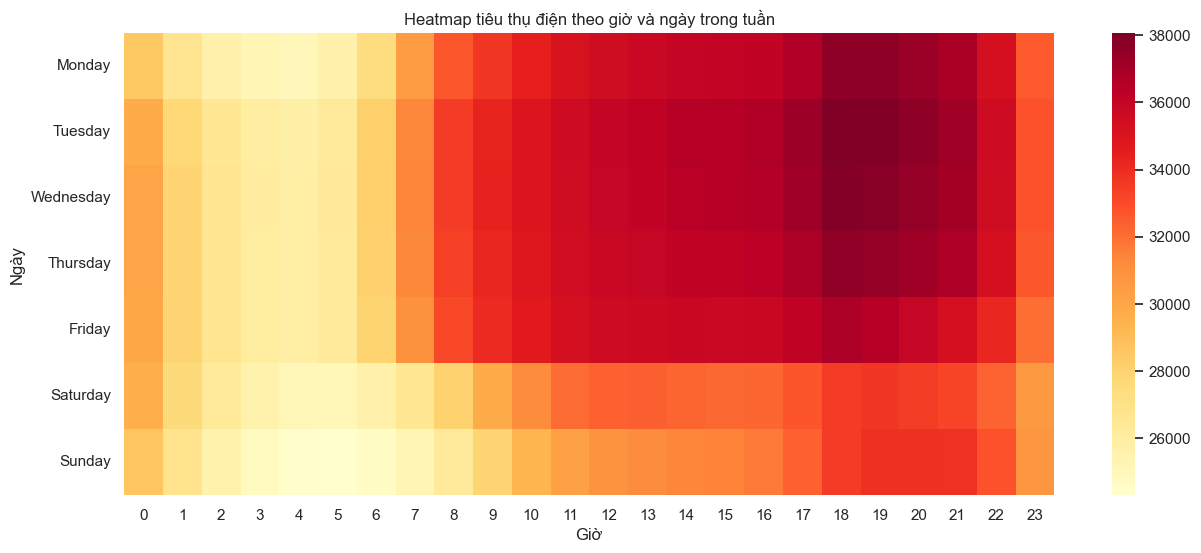

In [16]:
heatmap_data = eda_df.pivot_table(
    values="PJME_MW",
    index="day_name",
    columns="hour",
    aggfunc="mean"
).reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])

plt.figure(figsize=(15,6))
sns.heatmap(heatmap_data, cmap="YlOrRd")
plt.title("Heatmap tiêu thụ điện theo giờ và ngày trong tuần")
plt.xlabel("Giờ")
plt.ylabel("Ngày")
plt.show()

Nhận xét :

Heatmap cho thấy mức tiêu thụ điện thay đổi rõ theo cả **giờ trong ngày** và **ngày trong tuần**. Nhìn chung,** mức tiêu thụ thấp nhất thường rơi vào rạng sáng khoảng 3h đến 5h**, sau đó tăng dần từ buổi sáng và **cao nhất vào chiều tối, khoảng 17h đến 20h**. Các ngày trong tuần như thứ Hai đến thứ Sáu có cường độ màu đậm hơn, tức là tiêu thụ điện cao hơn so với cuối tuần, đặc biệt Chủ nhật là thấp hơn rõ rệt. Điều này cho thấy dữ liệu có tính chu kỳ rất rõ theo giờ và theo ngày, nên hai đặc trưng này rất quan trọng trong mô hình dự báo điện năng.

###15. Xem các thời điểm tiêu thụ cao nhất và thấp nhất

In [17]:
print("10 thời điểm tiêu thụ cao nhất:")
print(df.nlargest(10, "PJME_MW"))

print("\n10 thời điểm tiêu thụ thấp nhất:")
print(df.nsmallest(10, "PJME_MW"))

10 thời điểm tiêu thụ cao nhất:
                 Datetime  PJME_MW
40183 2006-08-02 17:00:00    62009
40182 2006-08-02 16:00:00    61909
40207 2006-08-03 17:00:00    61796
40206 2006-08-03 16:00:00    61770
83730 2011-07-22 15:00:00    61646
40159 2006-08-01 17:00:00    61643
40181 2006-08-02 15:00:00    61641
40184 2006-08-02 18:00:00    61610
83731 2011-07-22 16:00:00    61608
83729 2011-07-22 14:00:00    61532

10 thời điểm tiêu thụ thấp nhất:
                 Datetime  PJME_MW
94901 2012-10-30 04:00:00    14544
94900 2012-10-30 03:00:00    14586
94902 2012-10-30 05:00:00    14821
94899 2012-10-30 02:00:00    14955
94898 2012-10-30 01:00:00    15390
94903 2012-10-30 06:00:00    15526
94897 2012-10-30 00:00:00    15919
94904 2012-10-30 07:00:00    16688
94896 2012-10-29 23:00:00    17422
94905 2012-10-30 08:00:00    17734


Nhận xét :

Kết quả cho thấy các** thời điểm tiêu thụ điện cao nhất tập trung chủ yếu vào đầu tháng 8/2006 và tháng 7/2011**, với mức cao nhất lên tới 62.009 MW. Ngược lại, các **thời điểm tiêu thụ điện thấp nhất đều rơi vào rạng sáng** ngày 30/10/2012, với mức thấp nhất chỉ 14.544 MW. Điều này cho thấy dữ liệu có biên độ dao động rất lớn giữa các giai đoạn cao điểm và thấp điểm. Các mốc cực đại và cực tiểu này phản ánh những thời điểm nhu cầu điện biến động mạnh, rất đáng chú ý khi phân tích đặc điểm dữ liệu và xây dựng mô hình dự báo.

###16. Phân tích sự khác biệt giữa Ngày thường và Cuối tuần

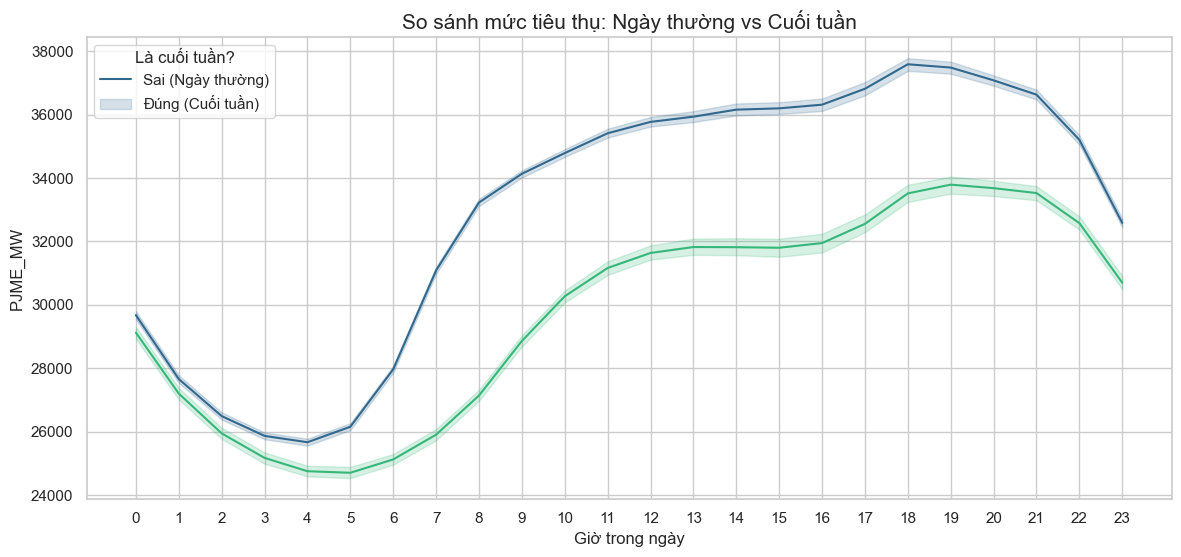

In [18]:
# Tạo biến phân loại ngày nghỉ
eda_df['is_weekend'] = eda_df['dayofweek'].isin([5, 6])

plt.figure(figsize=(14, 6))
sns.lineplot(data=eda_df, x='hour', y='PJME_MW', hue='is_weekend', palette='viridis', errorbar=('ci', 95))
plt.title("So sánh mức tiêu thụ: Ngày thường vs Cuối tuần", fontsize=15)
plt.xlabel("Giờ trong ngày")
plt.ylabel("PJME_MW")
plt.xticks(range(24))
plt.legend(title='Là cuối tuần?', labels=['Sai (Ngày thường)', 'Đúng (Cuối tuần)'])
plt.show()

Nhận xét :

Biểu đồ cho thấy mức tiêu thụ điện vào ngày thường luôn cao hơn cuối tuần ở hầu hết các khung giờ. Cả hai nhóm đều có quy luật khá giống nhau: giảm xuống mức thấp nhất vào rạng sáng, sau đó tăng dần từ buổi sáng và đạt đỉnh vào khoảng **18h đến 19h**. Tuy nhiên, đường của ngày thường cao hơn rõ rệt, đặc biệt từ khoảng **7h đến 21h**, cho thấy nhu cầu điện trong ngày làm việc lớn hơn do hoạt động sản xuất, kinh doanh và sinh hoạt diễn ra mạnh hơn. Điều này chứng tỏ yếu tố ngày thường hay cuối tuần ảnh hưởng rõ đến mức tiêu thụ điện và là một đặc trưng quan trọng trong bài toán dự báo.

###17.Phân tích sự khác biệt giữa ngày thường và ngày lễ


####17.1. Tạo biến ngày lễ

In [19]:
from pandas.tseries.holiday import USFederalHolidayCalendar

# Tạo danh sách ngày lễ trong khoảng thời gian của dữ liệu
cal = USFederalHolidayCalendar()
holidays = cal.holidays(start=eda_df["Datetime"].min(), end=eda_df["Datetime"].max())

# Chuẩn hóa về ngày để so sánh
eda_df["date_only"] = eda_df["Datetime"].dt.normalize()
eda_df["is_holiday"] = eda_df["date_only"].isin(holidays)

# Tạo biến phân loại loại ngày
eda_df["day_type"] = np.where(
    eda_df["is_holiday"], "Holiday",
    np.where(eda_df["dayofweek"] < 5, "Weekday", "Weekend")
)

eda_df[["Datetime", "day_name", "is_holiday", "day_type"]].head()

,Datetime,day_name,is_holiday,day_type
0,2002-01-01 01:00:00,Tuesday,False,Weekday
1,2002-01-01 02:00:00,Tuesday,False,Weekday
2,2002-01-01 03:00:00,Tuesday,False,Weekday
3,2002-01-01 04:00:00,Tuesday,False,Weekday
4,2002-01-01 05:00:00,Tuesday,False,Weekday


####17.2. So sánh mức tiêu thụ trung bình giữa ngày thường và ngày lễ

day_type
Holiday    31147.662348
Weekday    33068.894271
Name: PJME_MW, dtype: float64


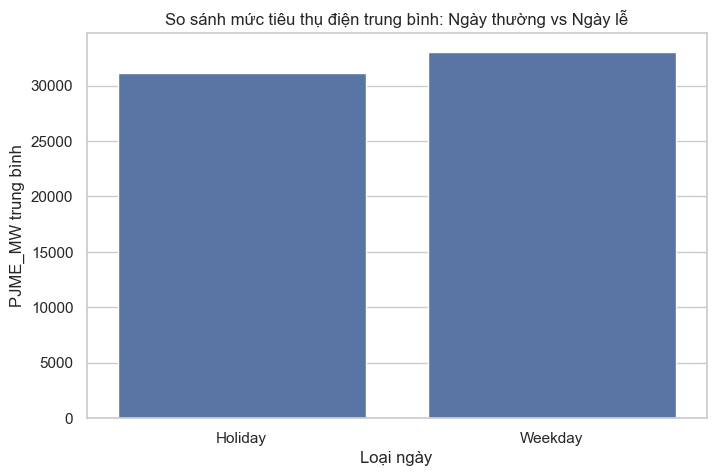

In [20]:
compare_holiday = eda_df[eda_df["day_type"].isin(["Weekday", "Holiday"])]

holiday_mean = compare_holiday.groupby("day_type")["PJME_MW"].mean()
print(holiday_mean)

plt.figure(figsize=(8,5))
sns.barplot(x=holiday_mean.index, y=holiday_mean.values)
plt.title("So sánh mức tiêu thụ điện trung bình: Ngày thường vs Ngày lễ")
plt.xlabel("Loại ngày")
plt.ylabel("PJME_MW trung bình")
plt.show()

Nhận xét :

Biểu đồ cho thấy mức tiêu thụ điện **trung bình vào ngày thường cao hơn ngày lễ**. Cụ thể, mức tiêu thụ trung bình của ngày lễ khoảng 31.147 MW, trong khi ngày thường khoảng 33.069 MW, chênh lệch gần 2.000 MW. Điều này cho thấy vào ngày lễ, nhu cầu sử dụng điện có xu hướng giảm, có thể do các hoạt động sản xuất, kinh doanh và làm việc tại cơ quan giảm xuống. Vì vậy, yếu tố ngày lễ cũng có ảnh hưởng nhất định đến mức tiêu thụ điện và nên được xem là một đặc trưng hữu ích trong mô hình dự báo.

####17.3. So sánh theo từng khung giờ trong ngày

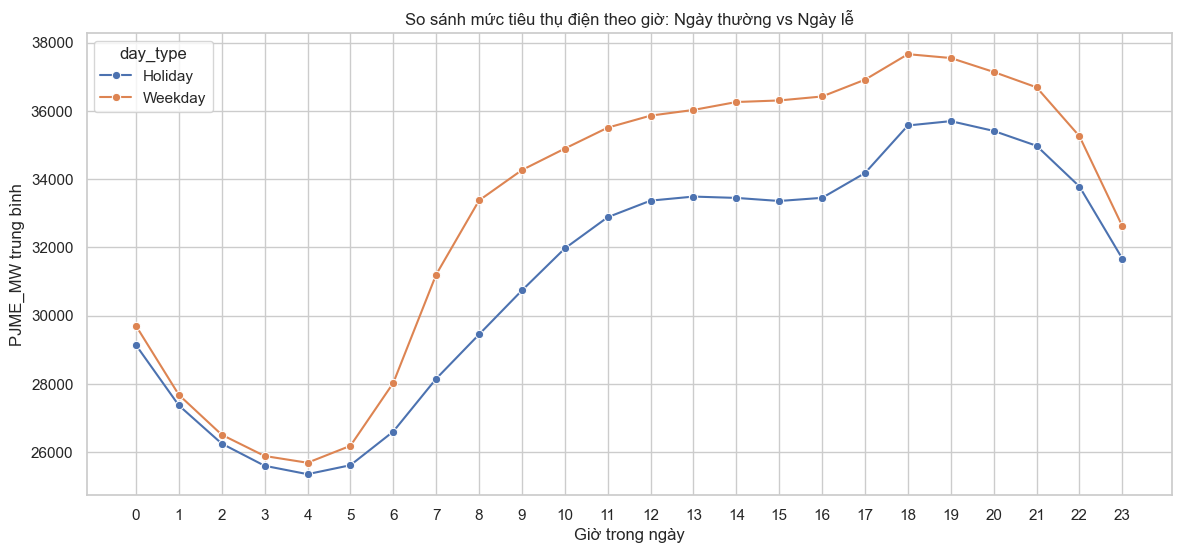

In [21]:
hourly_holiday = compare_holiday.groupby(["hour", "day_type"])["PJME_MW"].mean().reset_index()

plt.figure(figsize=(14,6))
sns.lineplot(data=hourly_holiday, x="hour", y="PJME_MW", hue="day_type", marker="o")
plt.title("So sánh mức tiêu thụ điện theo giờ: Ngày thường vs Ngày lễ")
plt.xlabel("Giờ trong ngày")
plt.ylabel("PJME_MW trung bình")
plt.xticks(range(24))
plt.show()

Nhận xét :

Biểu đồ cho thấy** mức tiêu thụ điện vào ngày thường luôn cao hơn ngày lễ **ở hầu hết các khung giờ trong ngày. Cả hai đường đều có xu hướng giống nhau: giảm xuống mức thấp nhất vào khoảng 3h đến 4h sáng, sau đó tăng dần từ buổi sáng và đạt mức cao vào chiều tối, đặc biệt khoảng 18h đến 19h. Tuy nhiên, chênh lệch giữa hai nhóm rõ nhất trong khoảng 7h đến 21h, khi ngày thường có mức tiêu thụ cao hơn đáng kể so với ngày lễ. Điều này cho thấy vào ngày lễ, nhu cầu sử dụng điện giảm do hoạt động làm việc, sản xuất và kinh doanh ít hơn, nên yếu tố ngày lễ có ảnh hưởng rõ rệt đến mô hình tiêu thụ điện.

In [22]:
print("Số ngày lễ trong dữ liệu:", eda_df["date_only"][eda_df["is_holiday"]].nunique())
print("Một vài ngày lễ đầu tiên:")
print(sorted(eda_df["date_only"][eda_df["is_holiday"]].drop_duplicates().astype(str).tolist())[:10])

Số ngày lễ trong dữ liệu: 164
Một vài ngày lễ đầu tiên:
['2002-01-21', '2002-02-18', '2002-05-27', '2002-07-04', '2002-09-02', '2002-10-14', '2002-11-11', '2002-11-28', '2002-12-25', '2003-01-01']


Kết quả cho thấy bộ dữ liệu có 164 ngày lễ. Điều này cho thấy biến is_holiday đã được tạo thành công và dữ liệu có đủ số lượng ngày lễ để so sánh với ngày thường. Nhờ đó, việc phân tích ảnh hưởng của ngày lễ đến mức tiêu thụ điện sẽ có cơ sở rõ ràng và đáng tin cậy hơn.

###18. Phân tích Mùa vụ theo năm (Seasonal Boxplot)

*Mục tiêu: Kiểm tra xem qua các năm, quy luật theo tháng có thay đổi không.*

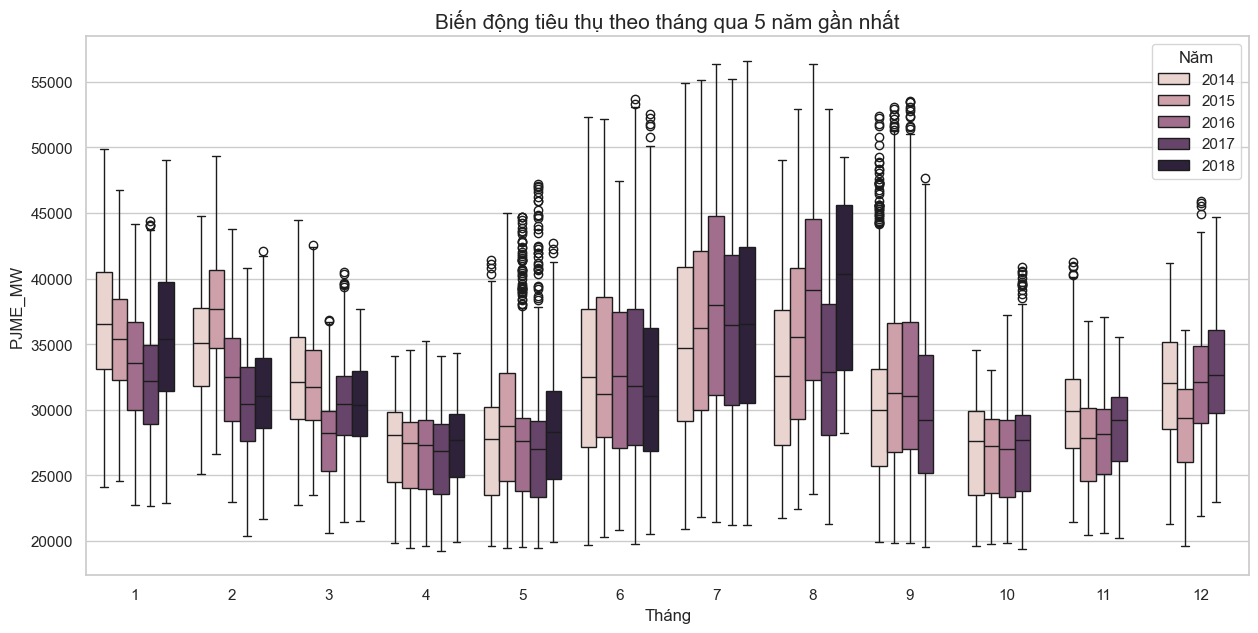

In [23]:
plt.figure(figsize=(15, 7))
# Chọn 5 năm gần nhất để biểu đồ không bị quá dày
latest_years = eda_df['year'].unique()[-5:]
sns.boxplot(data=eda_df[eda_df['year'].isin(latest_years)], x='month', y='PJME_MW', hue='year')
plt.title("Biến động tiêu thụ theo tháng qua 5 năm gần nhất", fontsize=15)
plt.xlabel("Tháng")
plt.ylabel("PJME_MW")
plt.legend(title='Năm', bbox_to_anchor=(1, 1))
plt.show()

Nhận xét :

Biểu đồ boxplot cho thấy mức tiêu thụ điện trong 5 năm gần nhất thay đổi khá rõ theo từng tháng và có tính mùa vụ ổn định. Nhìn chung, các tháng mùa hè như 7 và 8 có mức tiêu thụ cao hơn hẳn, đồng thời độ phân tán cũng lớn hơn, cho thấy nhu cầu điện tăng mạnh và biến động nhiều hơn trong giai đoạn này. Ngược lại, các tháng như 4, 10 và 11 có mức tiêu thụ thấp hơn và ổn định hơn. Ngoài ra, sự khác biệt giữa các năm trong cùng một tháng cho thấy nhu cầu điện không chỉ phụ thuộc vào mùa mà còn chịu tác động của các yếu tố khác như thời tiết và mức sử dụng điện thực tế từng năm.

###19. Chuẩn hóa chuỗi thời gian để decomposition

In [24]:
clean_series = df.groupby("Datetime")["PJME_MW"].mean().sort_index()
clean_series = clean_series.asfreq("h")
clean_series = clean_series.interpolate(method="time")

print(clean_series.head())
print(clean_series.isnull().sum())

Datetime
2002-01-01 01:00:00    30393.0
2002-01-01 02:00:00    29265.0
2002-01-01 03:00:00    28357.0
2002-01-01 04:00:00    27899.0
2002-01-01 05:00:00    28057.0
Freq: h, Name: PJME_MW, dtype: float64
0


Cell 18 dùng để chuẩn hóa chuỗi thời gian trước khi làm các phân tích sâu hơn trong EDA, đặc biệt là decomposition.

Cụ thể:

- groupby("Datetime")["PJME_MW"].mean(): dùng để gộp các mốc thời gian bị trùng và lấy giá trị trung bình. Điều này giúp mỗi thời điểm chỉ còn 1 giá trị duy nhất.

- .sort_index() :dùng để sắp xếp dữ liệu theo đúng thứ tự thời gian, rất quan trọng với dữ liệu chuỗi thời gian.

- .asfreq("h"): dùng để ép dữ liệu về tần suất đều theo từng giờ. Nếu có giờ nào bị thiếu, pandas sẽ chèn mốc đó vào và để giá trị là NaN.

- .interpolate(method="time"): dùng để nội suy các giờ bị thiếu dựa trên thời gian, giúp chuỗi trở nên liên tục.

Tóm lại : Đoạn mã này dùng để chuẩn hóa chuỗi thời gian về dạng liên tục theo từng giờ bằng cách xử lý các mốc thời gian trùng, sắp xếp lại dữ liệu và nội suy các giá trị còn thiếu. Bước này rất quan trọng trong EDA vì giúp dữ liệu phù hợp cho các phân tích chuỗi thời gian như xu hướng, mùa vụ và decomposition. Nhờ đó, kết quả trực quan hóa và phân tích sẽ chính xác và ổn định hơn.

###20. Seasonal decomposition (trên 90 ngày cuối )

*phân rã chuỗi thời gian : là kỹ thuật thống kê giúp chia nhỏ một chuỗi dữ liệu phức tạp thành các thành phần đơn giản để dễ quan sát và phân tích*

In [39]:
!pip install statsmodels

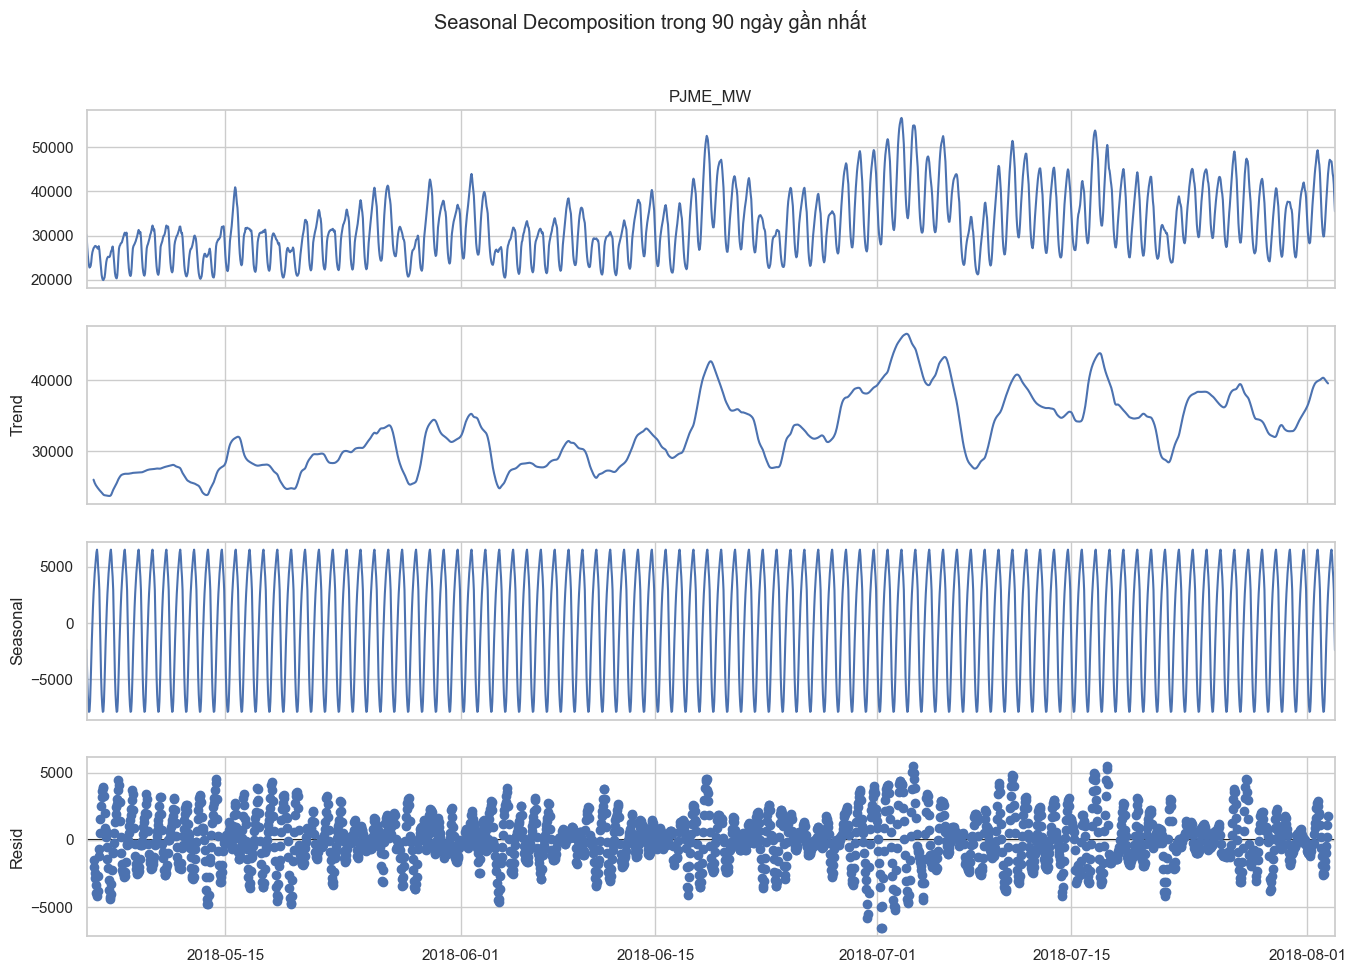

In [40]:
from statsmodels.tsa.seasonal import seasonal_decompose
import pandas as pd

recent_90d = clean_series.loc[
    clean_series.index >= clean_series.index.max() - pd.Timedelta(days=90)
]

decompose_recent = seasonal_decompose(
    recent_90d,
    model="additive",
    period=24
)

fig = decompose_recent.plot()
fig.set_size_inches(16,10)
plt.suptitle("Seasonal Decomposition trong 90 ngày gần nhất", y=1.02)
plt.show()

Nhận xét :

Biểu đồ decomposition **trên 90 ngày cuối** cho thấy dữ liệu tiêu thụ điện vẫn giữ được cấu trúc chuỗi thời gian rất rõ. Ở phần **Trend**, mức tiêu thụ điện có xu hướng tăng dần từ giữa tháng 5 đến đầu tháng 7, sau đó dao động lên xuống nhưng vẫn duy trì ở mức tương đối cao. Phần **Seasonal** thể hiện chu kỳ lặp lại rất đều theo ngày, cho thấy yếu tố mùa vụ theo giờ là rất rõ ràng và ổn định. Trong khi đó, **Residual** phân bố quanh mức 0 nhưng vẫn xuất hiện một số điểm biến động mạnh, đặc biệt vào đầu tháng 7, phản ánh những thời điểm tiêu thụ điện bất thường chưa được giải thích hoàn toàn bởi xu hướng và mùa vụ. Nhìn chung, kết quả này cho thấy dữ liệu có xu hướng, mùa vụ và nhiễu, rất phù hợp cho các mô hình dự báo chuỗi thời gian.

###21. Thống kê và mô tả

####21.1. Thống kê số lượng theo loại ngày

Số lượng bản ghi theo loại ngày:
day_type
Weekday    99935
Weekend    41495
Holiday     3936
Name: count, dtype: int64


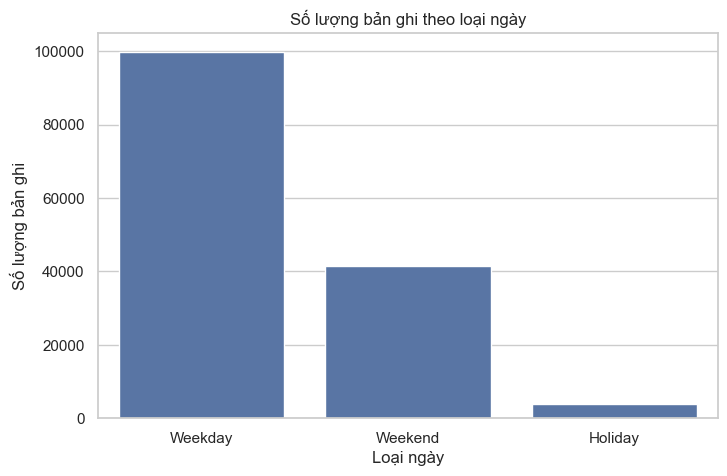

In [41]:
day_type_counts = eda_df["day_type"].value_counts()
print("Số lượng bản ghi theo loại ngày:")
print(day_type_counts)

plt.figure(figsize=(8,5))
sns.barplot(x=day_type_counts.index, y=day_type_counts.values)
plt.title("Số lượng bản ghi theo loại ngày")
plt.xlabel("Loại ngày")
plt.ylabel("Số lượng bản ghi")
plt.show()

Nhận xét :

Biểu đồ cho thấy số lượng bản ghi trong dữ liệu tập trung chủ yếu ở ngày thường, với 99.935 , cao hơn nhiều so với cuối tuần là 41.495  và ngày lễ là 3.936 . Sự chênh lệch này là hợp lý vì trong một năm số ngày thường luôn nhiều hơn số ngày cuối tuần và ngày lễ. Điều này cũng cho thấy khi phân tích hoặc xây dựng mô hình, nhóm ngày lễ có số lượng dữ liệu ít hơn đáng kể, nên cần được xem xét cẩn thận để tránh mất cân bằng khi so sánh. Tuy vậy, dữ liệu vẫn đủ để đánh giá ảnh hưởng của từng loại ngày đến mức tiêu thụ điện.

####21.2. Thống kê mô tả mức tiêu thụ điện theo loại ngày

In [42]:
desc_day_type = eda_df.groupby("day_type")["PJME_MW"].describe()
print("Thống kê mô tả mức tiêu thụ điện theo loại ngày:")
print(desc_day_type)

Thống kê mô tả mức tiêu thụ điện theo loại ngày:
            count          mean          std      min      25%      50%  \
day_type                                                                  
Holiday    3936.0  31147.662348  5770.354305  19414.0  27084.5  30706.5   
Weekday   99935.0  33068.894271  6542.232550  14544.0  28884.0  32317.0   
Weekend   41495.0  29787.601494  5696.242481  19247.0  25875.0  28864.0   

              75%      max  
day_type                    
Holiday   34524.0  53396.0  
Weekday   36602.5  62009.0  
Weekend   32942.0  56545.0  


Nhận xét :

Bảng thống kê mô tả cho thấy mức tiêu thụ điện có sự khác biệt rõ giữa ngày thường, cuối tuần và ngày lễ. Trong đó, ngày thường có mức tiêu thụ điện trung bình cao nhất, khoảng 33.069 MW, tiếp theo là ngày lễ khoảng 31.148 MW, còn cuối tuần thấp nhất, khoảng 29.788 MW. Giá trị trung vị cũng cho kết quả tương tự, cho thấy xu hướng này khá ổn định chứ không chỉ do một vài giá trị lớn bất thường.

Về mức độ biến động, ngày lễ có độ lệch chuẩn lớn nhất, cho thấy nhu cầu điện trong các ngày lễ dao động mạnh hơn so với hai nhóm còn lại. Ngoài ra, giá trị lớn nhất của ngày thường lên tới 62.009 MW, cao hơn rõ rệt so với cuối tuần và ngày lễ, phản ánh những giai đoạn cao điểm điện năng chủ yếu xuất hiện trong các ngày làm việc. Nhìn chung, kết quả này cho thấy loại ngày là một đặc trưng thời gian quan trọng và có ảnh hưởng đáng kể đến mức tiêu thụ điện.

####21.3. Thống kê riêng giữa ngày thường và ngày lễ

In [43]:
compare_holiday_desc = compare_holiday.groupby("day_type")["PJME_MW"].agg(
    count="count",
    mean="mean",
    median="median",
    std="std",
    min="min",
    max="max"
)

print("Thống kê mô tả: Ngày thường vs Ngày lễ")
print(compare_holiday_desc)

Thống kê mô tả: Ngày thường vs Ngày lễ
          count          mean   median          std    min    max
day_type                                                         
Holiday    3936  31147.662348  30706.5  5770.354305  19414  53396
Weekday   99935  33068.894271  32317.0  6542.232550  14544  62009


Nhận xét :

Bảng thống kê cho thấy ngày thường có mức tiêu thụ điện trung bình cao hơn ngày lễ. Cụ thể, ngày thường đạt khoảng 33.069 MW, trong khi ngày lễ khoảng 31.148 MW. Trung vị cũng có cùng xu hướng, với ngày thường là 32.317 MW và ngày lễ là 30.706,5 MW, cho thấy mức tiêu thụ điện trong ngày thường nhìn chung cao hơn khá ổn định.

Ngoài ra, ngày lễ có độ lệch chuẩn khoảng 5.770 MW, thấp hơn không nhiều so với 6.542 MW của ngày thường, nghĩa là cả hai nhóm đều có biến động nhưng ngày thường dao động mạnh hơn. Giá trị lớn nhất của ngày thường lên tới 62.009 MW, cao hơn rõ rệt so với 53.396 MW của ngày lễ. Điều này cho thấy các mức tiêu thụ điện rất cao chủ yếu xuất hiện trong ngày thường, khi hoạt động sản xuất, kinh doanh và làm việc diễn ra mạnh hơn. Nhìn chung, kết quả này tiếp tục khẳng định ngày lễ là một yếu tố có ảnh hưởng đến nhu cầu tiêu thụ điện và nên được xem xét trong mô hình dự báo.

####21.4. Mức chênh lệch giữa ngày thường và ngày lễ

In [44]:
weekday_mean = compare_holiday_desc.loc["Weekday", "mean"]
holiday_mean = compare_holiday_desc.loc["Holiday", "mean"]

diff = weekday_mean - holiday_mean
pct = diff / holiday_mean * 100

print(f"Chênh lệch trung bình: {diff:.2f} MW")
print(f"Tỷ lệ chênh lệch: {pct:.2f}%")

Chênh lệch trung bình: 1921.23 MW
Tỷ lệ chênh lệch: 6.17%


Nhận xét:

Kết quả thống kê cho thấy mức tiêu thụ điện trung bình trong ngày thường cao hơn ngày lễ khoảng 1.921,23 MW, tương đương khoảng 6,17%. Mức chênh lệch này cho thấy yếu tố ngày lễ có ảnh hưởng khá rõ đến nhu cầu sử dụng điện. Nguyên nhân có thể là vào ngày lễ, các hoạt động sản xuất, kinh doanh và làm việc tại cơ quan giảm xuống, làm cho tổng mức tiêu thụ điện thấp hơn so với ngày thường.

####21.5. Thống kê giờ cao điểm và thấp điểm

In [45]:
hourly_stats = eda_df.groupby("hour")["PJME_MW"].mean()
print("Giờ cao điểm:", hourly_stats.idxmax(), "-", hourly_stats.max())
print("Giờ thấp điểm:", hourly_stats.idxmin(), "-", hourly_stats.min())

Giờ cao điểm: 19 - 36426.62991086167
Giờ thấp điểm: 4 - 25414.924727632882


Nhận xét:

Kết quả cho thấy giờ cao điểm của mức tiêu thụ điện trung bình là 19 giờ, với giá trị khoảng 36.426,63 MW, trong khi giờ thấp điểm là 4 giờ sáng, với giá trị khoảng 25.414,92 MW. Điều này phản ánh quy luật sử dụng điện trong thực tế: nhu cầu điện thấp nhất vào rạng sáng khi hầu hết hoạt động sinh hoạt và sản xuất giảm xuống, sau đó tăng dần trong ngày và đạt đỉnh vào buổi tối. Đây là một đặc trưng rất quan trọng của dữ liệu điện năng và có ý nghĩa lớn đối với bài toán dự báo nhu cầu điện.

#~~~ KẾT THÚC ~~~